test_elemental_mastery_high (__main__.TestElementalReaction.test_elemental_mastery_high) ... ok
test_elemental_mastery_zero (__main__.TestElementalReaction.test_elemental_mastery_zero) ... ok
test_invalid_reaction_type (__main__.TestElementalReaction.test_invalid_reaction_type) ... ok
test_invalid_trigger_order (__main__.TestElementalReaction.test_invalid_trigger_order) ... ok
test_melt_first_hit (__main__.TestElementalReaction.test_melt_first_hit) ... ok
test_melt_second_hit (__main__.TestElementalReaction.test_melt_second_hit) ... ok
test_multiple_atk_values (__main__.TestElementalReaction.test_multiple_atk_values) ... ok
test_vaporize_first_hit (__main__.TestElementalReaction.test_vaporize_first_hit) ... ok
test_vaporize_second_hit (__main__.TestElementalReaction.test_vaporize_second_hit) ... ok

----------------------------------------------------------------------
Ran 9 tests in 0.014s

OK
C:\Users\syyyyy\AppData\Local\Temp\ipykernel_19564\657797293.py:174: UserWarning: Glyph 9989


📊 测试执行统计报告
执行时间: 2026-08-20 23:41:43
总用例数: 9
✅ 通过: 9
❌ 失败: 0
通过率: 100.0%

📊 图表已保存至: images/test_result.png


D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


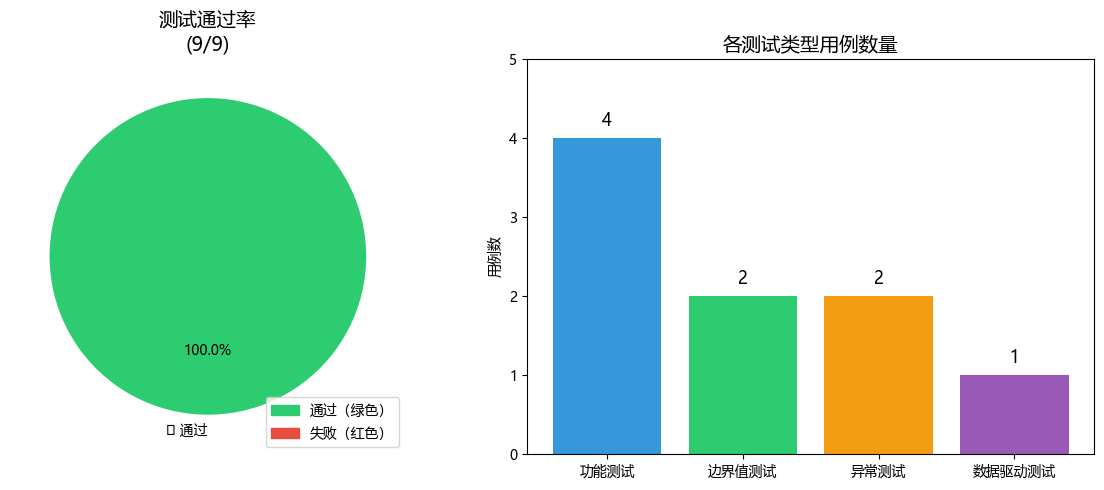

In [2]:
"""
原神元素反应伤害计算测试脚本
项目：https://github.com/3yyyyyyyyyyy/genshin-test
"""

import unittest
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['PingFang SC', 'Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False


class GenshinDamageCalculator:
    """模拟原神伤害计算的工具类（简化版）"""
    
    def __init__(self):
        self.enemy_defense = 0.5
        self.enemy_resistance = 0.1
        self.elemental_mastery = 0
    
    def set_elemental_mastery(self, em):
        self.elemental_mastery = em
    
    def calc_reaction_damage(self, base_damage, reaction_type, trigger_order):
        if reaction_type not in ['vaporize', 'melt']:
            raise KeyError(f"不支持的反应类型: {reaction_type}")
        if trigger_order not in ['first', 'second']:
            raise KeyError(f"不支持的触发顺序: {trigger_order}")
        
        if reaction_type == 'vaporize':
            multiplier = 1.5 if trigger_order == 'first' else 2.0
        elif reaction_type == 'melt':
            multiplier = 2.0 if trigger_order == 'first' else 1.5
        else:
            multiplier = 1.0
        
        em_bonus = 1 + (self.elemental_mastery / 1000)
        final_damage = (base_damage * multiplier * em_bonus * 
                        self.enemy_defense * (1 - self.enemy_resistance))
        return round(final_damage, 2)


class TestElementalReaction(unittest.TestCase):
    
    def setUp(self):
        self.calc = GenshinDamageCalculator()
        self.base_damage = 2000
    
    def test_vaporize_first_hit(self):
        result = self.calc.calc_reaction_damage(
            self.base_damage, 'vaporize', 'first'
        )
        expected = 2000 * 1.5 * 0.5 * 0.9
        self.assertEqual(result, expected)
    
    def test_vaporize_second_hit(self):
        result = self.calc.calc_reaction_damage(
            self.base_damage, 'vaporize', 'second'
        )
        expected = 2000 * 2.0 * 0.5 * 0.9
        self.assertEqual(result, expected)
    
    def test_melt_first_hit(self):
        result = self.calc.calc_reaction_damage(
            self.base_damage, 'melt', 'first'
        )
        expected = 2000 * 2.0 * 0.5 * 0.9
        self.assertEqual(result, expected)
    
    def test_melt_second_hit(self):
        result = self.calc.calc_reaction_damage(
            self.base_damage, 'melt', 'second'
        )
        expected = 2000 * 1.5 * 0.5 * 0.9
        self.assertEqual(result, expected)
    
    def test_elemental_mastery_zero(self):
        self.calc.set_elemental_mastery(0)
        result = self.calc.calc_reaction_damage(
            self.base_damage, 'vaporize', 'first'
        )
        expected = 2000 * 1.5 * 1.0 * 0.5 * 0.9
        self.assertEqual(result, expected)
    
    def test_elemental_mastery_high(self):
        self.calc.set_elemental_mastery(1000)
        result = self.calc.calc_reaction_damage(
            self.base_damage, 'vaporize', 'first'
        )
        expected = 2000 * 3.0 * 0.5 * 0.9
        self.assertEqual(result, expected)
    
    def test_invalid_reaction_type(self):
        with self.assertRaises(KeyError):
            self.calc.calc_reaction_damage(
                self.base_damage, 'overload', 'first'
            )
    
    def test_invalid_trigger_order(self):
        with self.assertRaises(KeyError):
            self.calc.calc_reaction_damage(
                self.base_damage, 'vaporize', 'third'
            )
    
    def test_multiple_atk_values(self):
        test_data = [
            (1000, 'first', 675.0),
            (2000, 'first', 1350.0),
            (3000, 'first', 2025.0),
            (2000, 'second', 1800.0),
        ]
        for atk, order, expected in test_data:
            with self.subTest(atk=atk, order=order):
                result = self.calc.calc_reaction_damage(
                    atk, 'vaporize', order
                )
                self.assertEqual(result, expected)


def generate_test_report(result, output_path='images/test_result.png'):
    """生成测试报告图表"""
    total = result.testsRun
    passed = total - len(result.failures) - len(result.errors)
    failed = len(result.failures) + len(result.errors)
    
    # 按测试类型统计
    test_types = {
        "功能测试": 4,
        "边界值测试": 2,
        "异常测试": 2,
        "数据驱动测试": 1,
    }
    
    # 创建图表
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # ===== 左图：通过率（饼图）=====
    if failed == 0:
        # 全部通过时显示完整绿饼
        labels = ['✅ 通过']
        colors = ['#2ecc71']
        sizes = [1]
        wedges, texts, autotexts = axes[0].pie(
            sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90
        )
        # 手动添加图例说明颜色含义
        axes[0].legend(
            [plt.Rectangle((0,0),1,1, color='#2ecc71'), 
             plt.Rectangle((0,0),1,1, color='#e74c3c')],
            ['通过（绿色）', '失败（红色）'],
            loc='lower right'
        )
    else:
        labels = ['✅ 通过', '❌ 失败']
        colors = ['#2ecc71', '#e74c3c']
        sizes = [passed, failed]
        axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    
    axes[0].set_title(f'测试通过率\n({passed}/{total})', fontsize=14)
    
    # ===== 右图：各类型分布（柱状图）=====
    types = list(test_types.keys())
    counts = list(test_types.values())
    bars = axes[1].bar(types, counts, color=['#3498db', '#2ecc71', '#f39c12', '#9b59b6'])
    axes[1].set_title('各测试类型用例数量', fontsize=14)
    axes[1].set_ylabel('用例数')
    axes[1].set_ylim(0, max(counts) + 1)
    
    for bar, count in zip(bars, counts):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                    str(count), ha='center', va='bottom', fontsize=12)
    
    plt.tight_layout()
    
    import os
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=150, bbox_inches='tight')
    print(f"\n📊 图表已保存至: {output_path}")
    
    plt.show()


def run_tests_with_report():
    """运行测试并生成报告"""
    suite = unittest.TestLoader().loadTestsFromTestCase(TestElementalReaction)
    runner = unittest.TextTestRunner(verbosity=2)
    result = runner.run(suite)
    
    total = result.testsRun
    passed = total - len(result.failures) - len(result.errors)
    failed = len(result.failures) + len(result.errors)
    
    print("\n" + "="*50)
    print("📊 测试执行统计报告")
    print("="*50)
    print(f"执行时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"总用例数: {total}")
    print(f"✅ 通过: {passed}")
    print(f"❌ 失败: {failed}")
    print(f"通过率: {round(passed/total*100, 1)}%")
    print("="*50)
    
    generate_test_report(result)
    
    return result


if __name__ == '__main__':
    run_tests_with_report()